# MES Bollinger Band mean-reversion, SHORT-ONLY, 30-minute bars (Tradovate exchange)

A dedicated, independently-tuned short-only study -- not just "take the
long-tuned combo and check its short side" (which `bollinger_mean_reversion_
mes_30m.ipynb`'s direction comparison already did, and
found decisively negative: MES short -0.45 Sharpe, MNQ short -0.35 Sharpe,
using parameters tuned for the *long* side). This notebook re-grids
`bb_length`/`bb_std_dev`/`sl_percent`/`tp_percent` from scratch with
`direction=short` fixed throughout, in case the short side has its own
distinct optimum that a long-tuned combo's parameters would never reveal.

**Why this is worth checking properly rather than assuming**: the
combination-portfolio notebook's finding was that combining long-only
sleeves doesn't diversify drawdown, because every sleeve shares the same
directional exposure. A genuinely-tuned short-mean-reversion edge -- if one
exists -- would be exactly the kind of different exposure profile that could
actually diversify that portfolio, rather than just adding more correlated
long risk. Worth ruling in or out properly rather than assuming shorting
fails here the way it has for every trend-following mechanism (Donchian,
SuperTrend, Keltner, Bollinger-squeeze) -- mean-reversion is a structurally
different bet (fading a move, not following one), so the same long-only bias
isn't guaranteed to carry over.

**Plan**: identical escalating-refinement process as the long-only notebooks
-- grid `bb_length` x `bb_std_dev` (direction=short throughout), then grid
`sl_percent` x `tp_percent` on the winner, then holdout, then walk-forward if
promising.


In [1]:
import os
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import HTML, display

from backtester.backtest_runner import Backtester
from backtester.exchange import Exchange, MarginAllocationType, MarketType, TradovateSymbolConfigProvider
from backtester.exchange.event_log import OrderFilled
from backtester.exchange_config import TRADOVATE_FUTURES
from backtester.indicators import Indicators
from backtester.market import Market
from backtester.middleware import MaxDailyLossMiddleware, TradeifyDrawdownMiddleware
from backtester.performance import PerformanceAnalyzer
from backtester.portfolio import Portfolio, WeightedStrategy
from backtester.strategies import BollingerMeanReversionStrategy, StrategyDirection
from data_aggregator.databento_aggregator import load_1m_parquet_resampled

cwd = os.getcwd()
print(cwd)


/Users/nick/Documents/www/alphakit/notebooks/pipelines/breakout


In [2]:
def _find_upwards(relative_path: str, start: Path) -> Path:
    for ancestor in [start, *start.parents]:
        candidate = ancestor / relative_path
        if candidate.exists():
            return candidate
    raise FileNotFoundError(
        f"Could not find {relative_path} above {start} -- run "
        "data_aggregator.databento_aggregator to download it first."
    )


DISPLAY_SYMBOL = "MES"
SYMBOL = "MES/USD"
INTERVAL = 30
UNIT_OF_TIME = "minute"

data_path = _find_upwards("apps/backtester/datasets/databento/MES_c_0_1m.parquet", start=Path(cwd))
ohlc = load_1m_parquet_resampled(data_path, interval=INTERVAL, unit_of_time=UNIT_OF_TIME)
print(f"Bars: {len(ohlc)}  span: {ohlc.index[0]} -> {ohlc.index[-1]}")


Bars: 84421  span: 2019-05-05 22:29:59.999000 -> 2026-07-12 23:29:59.999000


## Phase 1: grid the indicator's own hyperparameters (bb_length x bb_std_dev), direction=short

`sl_percent=0.01`, `tp_percent=0.01` fixed at placeholder values for this
pass -- tuned properly in Phase 2. `direction=short` throughout this entire
notebook.


In [3]:
BB_LENGTH_CANDIDATES = [10, 20, 30, 50]
BB_STD_DEV_CANDIDATES = [1.5, 2.0, 2.5, 3.0]
PLACEHOLDER_SL_PERCENT = 0.01
PLACEHOLDER_TP_PERCENT = 0.01
DEPOSIT_USD = 50_000
DIRECTION = StrategyDirection.short


def run_bmr_backtest(ohlc_slice: pd.DataFrame, bb_length: int, bb_std_dev: float, sl_percent: float, tp_percent: float,
                      key: str, direction: StrategyDirection = DIRECTION):
    lower, _middle, upper = Indicators.bollinger_bands(ohlc_slice, length=bb_length, std_dev=bb_std_dev)

    market = Market()
    market.add_market(symbol=SYMBOL, df=ohlc_slice)
    market.add_indicator(symbol=SYMBOL, interval=INTERVAL, unit_of_time=UNIT_OF_TIME, indicator_name="bb_lower", df=lower)
    market.add_indicator(symbol=SYMBOL, interval=INTERVAL, unit_of_time=UNIT_OF_TIME, indicator_name="bb_upper", df=upper)
    market.compile()

    portfolio = Portfolio(weighted_strategies=[
        WeightedStrategy(weight=1.0, strategy=BollingerMeanReversionStrategy(
            key=key, market=market, symbol=SYMBOL, bb_lower_key="bb_lower", bb_upper_key="bb_upper",
            sl_percent=sl_percent, tp_percent=tp_percent, direction=direction,
        )),
    ], output_scale=1)

    symbol_config_provider = TradovateSymbolConfigProvider(symbols=TRADOVATE_FUTURES, default_fee_per_contract=0.0)
    exchange = Exchange(
        market=market, slippage=0.0, maker_fee=0.0, taker_fee=0.0,
        market_type=MarketType.future, max_leverage=10,
        margin_allocation_type=MarginAllocationType.cross,
        symbol_config_provider=symbol_config_provider,
    )
    reporter = PerformanceAnalyzer(market=market, exchange=exchange, portfolio=portfolio,
                                    benchmark_symbols=[SYMBOL], periods_per_year=252)

    market.reset()
    drawdown_middleware = TradeifyDrawdownMiddleware(drawdown_percent=0.5)
    daily_loss_middleware = MaxDailyLossMiddleware(max_loss_percent=0.5)
    backtest = Backtester(market=market, portfolio=portfolio, exchange=exchange, reporter=reporter,
                           middlewares=[daily_loss_middleware, drawdown_middleware])
    backtest.exchange.transactions.add_deposit(asset="USD", volume=DEPOSIT_USD)
    backtest.run_all()
    return backtest, drawdown_middleware


def _summarize(bt, drawdown_mw, **extra_cols):
    summary = bt.reporter.summary["algo"]
    total_fees = sum(e.fees_volume for e in bt.exchange.event_log.get_events() if isinstance(e, OrderFilled))
    row = {**extra_cols}
    row.update({
        "net_return_percent": summary["net_return_percent"], "sharpe_ratio": summary["sharpe_ratio"],
        "max_drawdown_percent": summary["max_drawdown_percent"], "closed_trades": summary["closed_trades"],
        "trades_per_year": round(summary["closed_trades"] / 7.2, 1), "win_rate_percent": summary["win_rate_percent"],
        "profit_factor": summary["profit_factor"], "r_multiple_expectancy": summary["r_multiple_expectancy"],
        "dollar_profit_factor": summary["dollar_profit_factor"], "dollar_expectancy": summary["dollar_expectancy"],
        "total_fees_usd": total_fees, "account_failed": drawdown_mw.account_failed,
    })
    return row


grid1_rows = []
grid1_backtests = {}
_t0 = time.time()
for bb_length in BB_LENGTH_CANDIDATES:
    for bb_std_dev in BB_STD_DEV_CANDIDATES:
        bt, drawdown_mw = run_bmr_backtest(ohlc, bb_length, bb_std_dev, PLACEHOLDER_SL_PERCENT, PLACEHOLDER_TP_PERCENT,
                                             key=f"BMRS_ind_{bb_length}_{bb_std_dev}")
        grid1_backtests[(bb_length, bb_std_dev)] = (bt, drawdown_mw)
        grid1_rows.append(_summarize(bt, drawdown_mw, bb_length=bb_length, bb_std_dev=bb_std_dev))
    print(f"bb_length={bb_length} done, {time.time() - _t0:.0f}s elapsed", flush=True)

grid1_results = pd.DataFrame(grid1_rows).sort_values("sharpe_ratio", ascending=False).reset_index(drop=True)
print("\nphase 1 grid done in " + f"{time.time() - _t0:.0f}s\n")
print(grid1_results.to_string())


bb_length=10 done, 23s elapsed


bb_length=20 done, 43s elapsed


bb_length=30 done, 63s elapsed


bb_length=50 done, 81s elapsed



phase 1 grid done in 81s

    bb_length  bb_std_dev  net_return_percent  sharpe_ratio  max_drawdown_percent  closed_trades  trades_per_year  win_rate_percent  profit_factor  r_multiple_expectancy  dollar_profit_factor  dollar_expectancy  total_fees_usd  account_failed
0          50         3.0           -8.940472     -0.169429              -14.5726          398.0             55.3         47.738693       0.931915              -0.035230              0.951836          -8.292697         1223.95           False
1          30         2.5          -22.989382     -0.319565              -27.3868          814.0            113.1         49.140049       0.985702              -0.007200              0.931732         -10.957489         2359.63           False
2          10         2.5          -26.519833     -0.349614              -33.1145          926.0            128.6         54.103672       1.202638               0.092083              0.938474         -11.193337         3073.98           False
3

### Heatmaps: Sharpe ratio and net return across (bb_length, bb_std_dev)


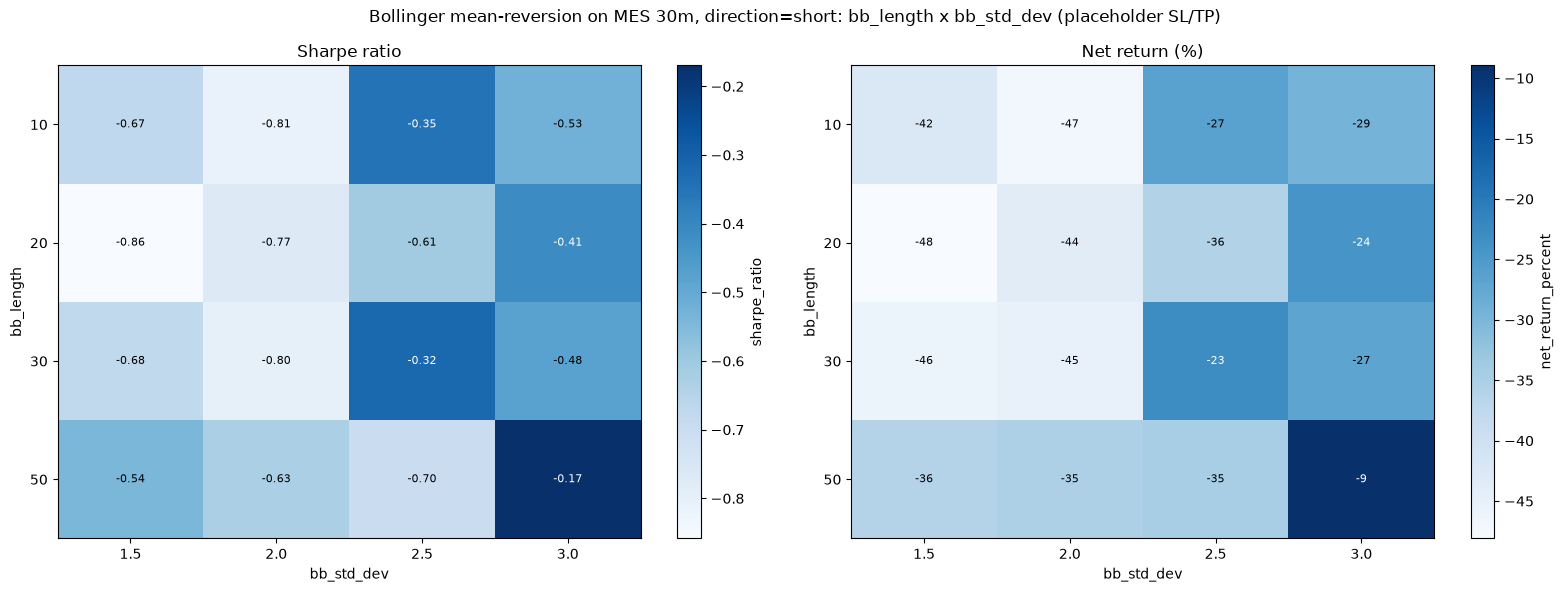

In [4]:
def _plot_heatmap(ax, pivot: pd.DataFrame, title: str, fmt: str, xlabel: str, ylabel: str):
    values = pivot.values.astype(float)
    vmin, vmax = np.nanmin(values), np.nanmax(values)
    span = vmax - vmin if vmax > vmin else 1.0
    im = ax.imshow(values, cmap="Blues", aspect="auto")
    ax.set_xticks(range(len(pivot.columns)), labels=[str(c) for c in pivot.columns])
    ax.set_yticks(range(len(pivot.index)), labels=[str(i) for i in pivot.index])
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    for i in range(values.shape[0]):
        for j in range(values.shape[1]):
            val = values[i, j]
            normalized = (val - vmin) / span
            ax.text(j, i, format(val, fmt), ha="center", va="center", fontsize=8,
                    color="white" if normalized > 0.6 else "black")
    return im


sharpe_pivot = grid1_results.pivot(index="bb_length", columns="bb_std_dev", values="sharpe_ratio")
return_pivot = grid1_results.pivot(index="bb_length", columns="bb_std_dev", values="net_return_percent")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
im0 = _plot_heatmap(axes[0], sharpe_pivot, "Sharpe ratio", ".2f", "bb_std_dev", "bb_length")
fig.colorbar(im0, ax=axes[0], label="sharpe_ratio")
im1 = _plot_heatmap(axes[1], return_pivot, "Net return (%)", ".0f", "bb_std_dev", "bb_length")
fig.colorbar(im1, ax=axes[1], label="net_return_percent")
fig.suptitle("Bollinger mean-reversion on MES 30m, direction=short: bb_length x bb_std_dev (placeholder SL/TP)")
fig.tight_layout()
plt.show()


## Phase 2: grid SL/TP on the best (bb_length, bb_std_dev) combo, direction=short

Holding the indicator shape fixed at Phase 1's winner, grids `sl_percent` x
`tp_percent` directly.


In [5]:
best_bb_length, best_bb_std_dev = grid1_results.iloc[0][["bb_length", "bb_std_dev"]]
best_bb_length = int(best_bb_length)
best_bb_std_dev = float(best_bb_std_dev)
print(f"Phase 1 winner: bb_length={best_bb_length}, bb_std_dev={best_bb_std_dev}")

SL_PERCENT_CANDIDATES = [0.005, 0.01, 0.015, 0.02]
TP_PERCENT_CANDIDATES = [0.0025, 0.005, 0.0075, 0.01]

grid2_rows = []
grid2_backtests = {}
_t0 = time.time()
for sl_percent in SL_PERCENT_CANDIDATES:
    for tp_percent in TP_PERCENT_CANDIDATES:
        bt, drawdown_mw = run_bmr_backtest(ohlc, best_bb_length, best_bb_std_dev, sl_percent, tp_percent,
                                             key=f"BMRS_sltp_{sl_percent}_{tp_percent}")
        grid2_backtests[(sl_percent, tp_percent)] = (bt, drawdown_mw)
        grid2_rows.append(_summarize(bt, drawdown_mw, sl_percent=sl_percent, tp_percent=tp_percent))
    print(f"sl_percent={sl_percent} done, {time.time() - _t0:.0f}s elapsed", flush=True)

grid2_results = pd.DataFrame(grid2_rows).sort_values("sharpe_ratio", ascending=False).reset_index(drop=True)
print("\nphase 2 grid done in " + f"{time.time() - _t0:.0f}s\n")
print(grid2_results.to_string())


Phase 1 winner: bb_length=50, bb_std_dev=3.0


sl_percent=0.005 done, 19s elapsed


sl_percent=0.01 done, 38s elapsed


sl_percent=0.015 done, 55s elapsed


sl_percent=0.02 done, 65s elapsed



phase 2 grid done in 65s

    sl_percent  tp_percent  net_return_percent  sharpe_ratio  max_drawdown_percent  closed_trades  trades_per_year  win_rate_percent  profit_factor  r_multiple_expectancy  dollar_profit_factor  dollar_expectancy  total_fees_usd  account_failed
0        0.010      0.0100           -8.940472     -0.169429              -14.5726          398.0             55.3         47.738693       0.931915              -0.035230              0.951836          -8.292697         1223.95           False
1        0.015      0.0100          -13.662177     -0.232641              -19.9750          333.0             46.2         57.657658       0.930726              -0.028899              0.918475         -17.588884         1036.49           False
2        0.005      0.0100           -9.974321     -0.243579              -18.6950          531.0             73.8         32.580038       0.981124              -0.012663              0.942301          -6.508425         1580.67           Fal

### Heatmaps: Sharpe ratio and net return across (sl_percent, tp_percent)


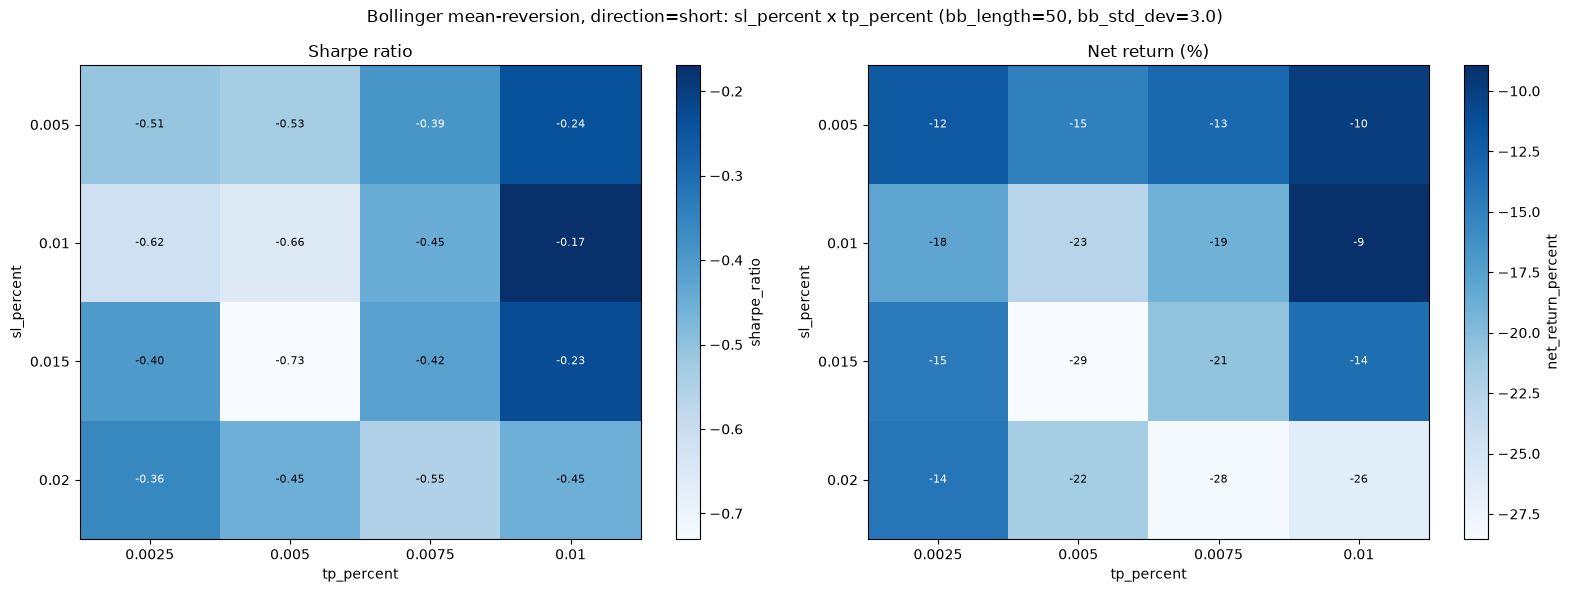

In [6]:
sharpe_pivot2 = grid2_results.pivot(index="sl_percent", columns="tp_percent", values="sharpe_ratio")
return_pivot2 = grid2_results.pivot(index="sl_percent", columns="tp_percent", values="net_return_percent")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
im0 = _plot_heatmap(axes[0], sharpe_pivot2, "Sharpe ratio", ".2f", "tp_percent", "sl_percent")
fig.colorbar(im0, ax=axes[0], label="sharpe_ratio")
im1 = _plot_heatmap(axes[1], return_pivot2, "Net return (%)", ".0f", "tp_percent", "sl_percent")
fig.colorbar(im1, ax=axes[1], label="net_return_percent")
fig.suptitle(f"Bollinger mean-reversion, direction=short: sl_percent x tp_percent (bb_length={best_bb_length}, bb_std_dev={best_bb_std_dev})")
fig.tight_layout()
plt.show()


## Detailed report for the overall best combo

Full HTML summary (year-by-year split) and equity/drawdown charts for the
best (bb_length, bb_std_dev, sl_percent, tp_percent) combo across both grids.


Best combo: bb_length=50, bb_std_dev=3.0, sl_percent=0.01, tp_percent=0.01
Candles Processed: 84420
Account failed (drawdown breach): False


metric,algo,algo_2019,algo_2020,algo_2021,algo_2022,algo_2023,algo_2024,algo_2025,algo_2026,MES/USD,description
sharpe_ratio,-0.1694,-2.3440,0.4491,-0.9197,1.1293,0.1465,-0.4612,-0.8720,0.2187,0.6392,"Return per unit of total volatility. <0 bad, ~1 decent, >2 great, >3 excellent."
sortino_ratio,-0.2467,-3.0331,0.6935,-1.2823,1.7580,0.2111,-0.6571,-1.2125,0.3300,0.9137,"Like Sharpe but only penalizes downside volatility (upside swings aren't ""risk""). >2 good, >3 excellent."
annualized_volatility_percent,4.6650,4.4026,4.9452,4.2663,5.6219,5.6125,3.7854,3.5970,4.4530,16.6830,How much the equity curve swings per year. Lower = smoother.
cagr_percent,-1.2938,-14.0071,3.0954,-5.6645,9.4075,0.9706,-2.6050,-4.5431,1.2826,14.3689,"Compound annual growth rate, the smoothed annual growth rate. Higher is generally better, but always weigh against volatility/drawdown."
calmar_ratio,-0.0888,-1.2778,0.8055,-0.8708,3.3087,0.1384,-0.3438,-0.5816,0.2847,0.4057,"CAGR ÷ max drawdown. >1 decent, >3 excellent, <0.5 weak."
recovery_factor,-0.6135,-0.8617,0.8055,-0.8685,3.2992,0.1380,-0.3438,-0.5801,0.1493,4.5918,Total net profit ÷ max drawdown. >2 solid.
max_drawdown_percent,-14.5726,-10.9619,-3.8430,-6.5049,-2.8432,-7.0146,-7.5764,-7.8107,-4.5052,-35.4168,Largest peak-to-trough loss. Closer to 0 better; below -20% starts getting painful for most investors.
max_drawdown_duration_days,1429,211,155,276,87,129,243,254,104,719,How long it took to recover the loss. Shorter is better.
ulcer_index,9.2292,6.2856,1.1896,4.0305,0.9463,2.2667,4.1245,3.3527,2.0713,8.4634,"Combines depth and duration of drawdowns into one number. Lower is better (less ""ulcer-inducing"")."
var_95_percent,-0.4947,-0.5075,-0.4977,-0.4648,-0.5145,-0.6380,-0.4710,-0.3989,-0.5195,-1.4858,"The daily loss you shouldn't exceed on a ""normal"" bad day (worst of the best 95%). Closer to 0 is better."


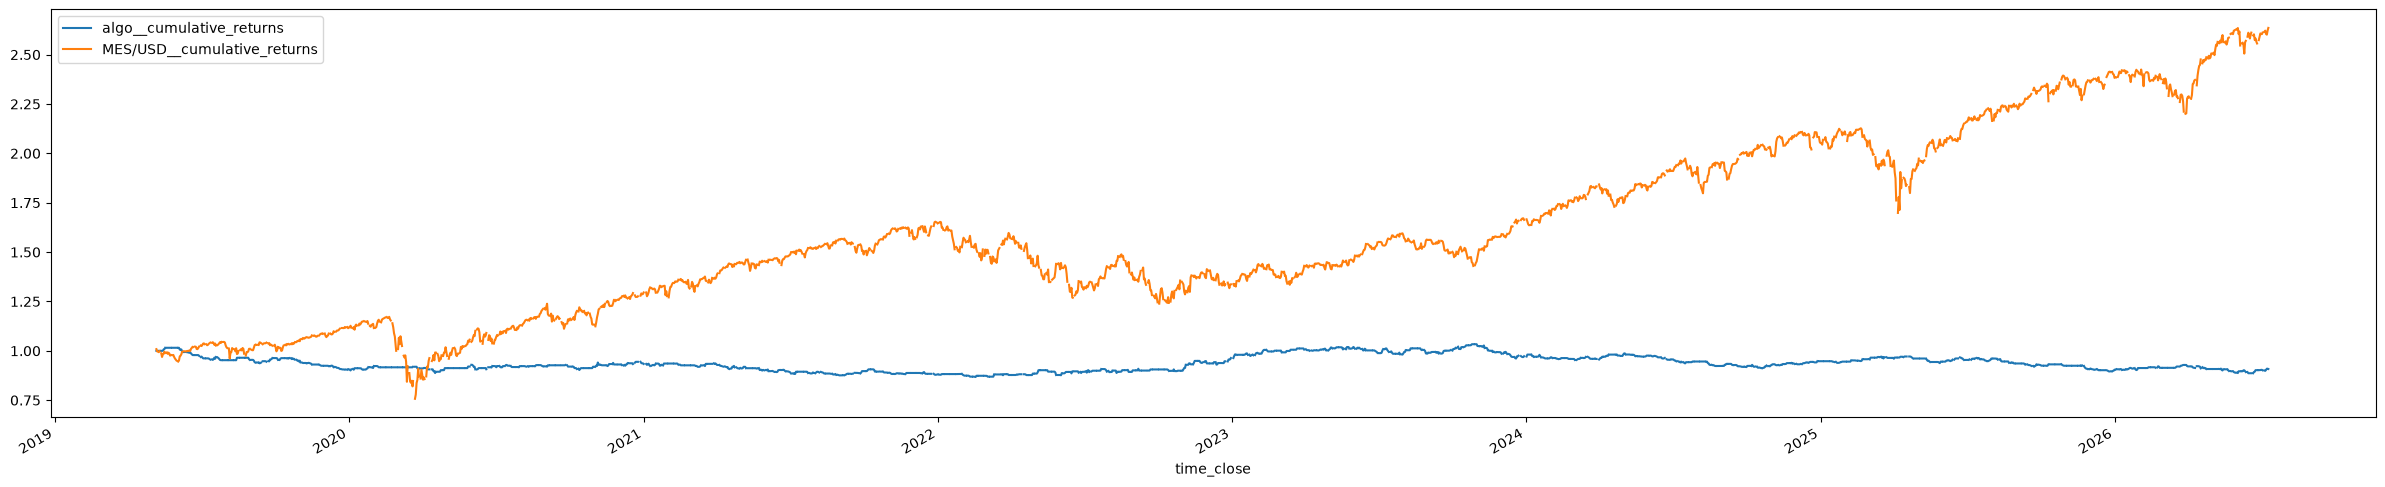

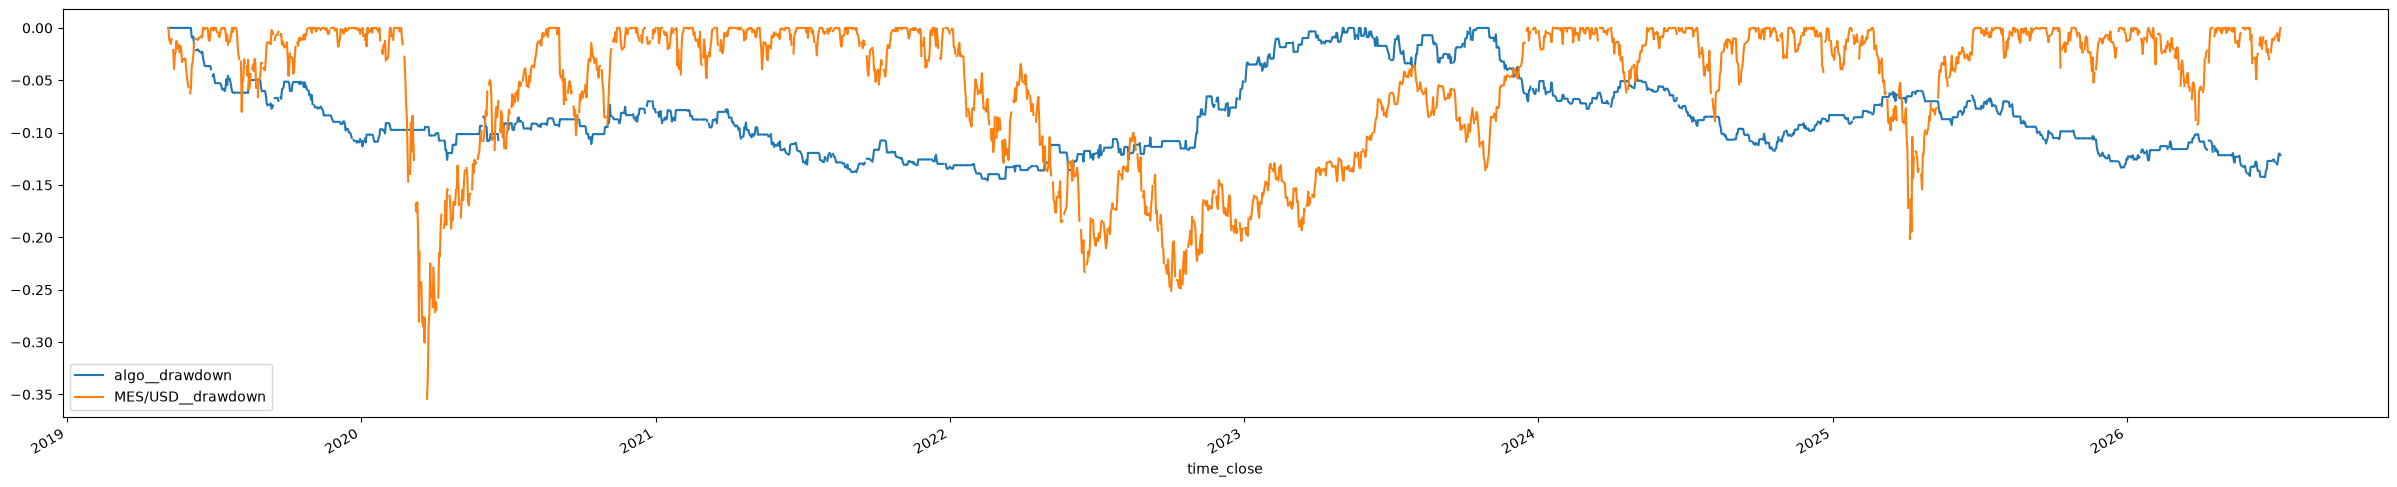

In [7]:
best_sl_percent, best_tp_percent = grid2_results.iloc[0][["sl_percent", "tp_percent"]]
best_sl_percent = float(best_sl_percent)
best_tp_percent = float(best_tp_percent)
print(f"Best combo: bb_length={best_bb_length}, bb_std_dev={best_bb_std_dev}, sl_percent={best_sl_percent}, tp_percent={best_tp_percent}")
best_backtest, best_drawdown_mw = grid2_backtests[(best_sl_percent, best_tp_percent)]

print("Candles Processed:", best_backtest.market.current["num"])
print("Account failed (drawdown breach):", best_drawdown_mw.account_failed)

display(HTML(best_backtest.reporter.summary_html_table(split="Y")))

if best_backtest.reporter.merged is not None:
    best_backtest.reporter.merged.plot(x="time_close", y=[
        "algo__cumulative_returns",
        f"{SYMBOL}__cumulative_returns",
    ], figsize=(30, 6))

    best_backtest.reporter.merged.plot(x="time_close", y=[
        "algo__drawdown",
        f"{SYMBOL}__drawdown",
    ], figsize=(30, 6))


## Holdout check: does the best combo survive a train/test split?


In [8]:
split_idx = int(len(ohlc) * 0.75)
split_date = ohlc.index[split_idx]
print(f"train/test split at {split_date}  ({split_idx} train bars, {len(ohlc) - split_idx} test bars)")

train_ohlc, test_ohlc = ohlc.loc[:split_date], ohlc.loc[split_date:]


def trade_sharpe_lb(trades: list, z: float = 1.645) -> tuple[float, float, int]:
    '''Lo (2002) Sharpe lower bound over a strategy's per-trade returns: point
    estimate minus z standard errors, SE(SR) ~= sqrt((1 + SR^2/2) / N). Returns
    (trade_sharpe, trade_sharpe_lb, n) -- NaN Sharpes if fewer than 2 trades or a
    zero-variance trade set (can't estimate a standard error from either).'''
    pnls = np.array([t.pnl for t in trades])
    n = len(pnls)
    if n < 2 or pnls.std(ddof=1) == 0:
        return float("nan"), float("nan"), n
    sr = pnls.mean() / pnls.std(ddof=1)
    se = np.sqrt((1 + sr**2 / 2) / n)
    return sr, sr - z * se, n


holdout_rows = []
for label, ohlc_slice in [
    ("FULL", ohlc),
    ("TRAIN (75%)", train_ohlc),
    ("TEST (last 25%, unseen)", test_ohlc),
]:
    bt, drawdown_mw = run_bmr_backtest(ohlc_slice, best_bb_length, best_bb_std_dev, best_sl_percent, best_tp_percent,
                                         key=f"BMRS_holdout_{label}")
    strategy = bt.portfolio.weighted_strategies[0].strategy
    trade_sharpe, sr_lb, n_trades = trade_sharpe_lb(strategy.trade_history)
    summary = bt.reporter.summary["algo"]
    holdout_rows.append({
        "window": label, "trades": n_trades, "win_rate_percent": summary["win_rate_percent"],
        "trade_sharpe": trade_sharpe, "trade_sharpe_lb": sr_lb,
        "account_sharpe": summary["sharpe_ratio"], "net_return_percent": summary["net_return_percent"],
        "dollar_profit_factor": summary["dollar_profit_factor"], "dollar_expectancy": summary["dollar_expectancy"],
        "max_drawdown_percent": summary["max_drawdown_percent"], "account_failed": drawdown_mw.account_failed,
    })

holdout_df = pd.DataFrame(holdout_rows).set_index("window")
print(holdout_df.to_string())


train/test split at 2024-09-20 07:59:59.999000  (63315 train bars, 21106 test bars)


                         trades  win_rate_percent  trade_sharpe  trade_sharpe_lb  account_sharpe  net_return_percent  dollar_profit_factor  dollar_expectancy  max_drawdown_percent  account_failed
window                                                                                                                                                                                             
FULL                        398         47.738693     -0.035218        -0.117700       -0.169429           -8.940472              0.951836          -8.292697              -14.5726           False
TRAIN (75%)                 303         47.854785     -0.032880        -0.127409       -0.188122           -7.806171              0.947711          -9.384689              -14.5726           False
TEST (last 25%, unseen)      94         47.872340     -0.032409        -0.202122       -0.061820           -0.739587              0.981324          -2.769189               -8.0446           False


## Findings

**Decisively negative, even independently tuned -- confirms rather than
overturns the earlier direction-comparison finding.** Every one of Phase 1's
16 combos and Phase 2's 16 combos is net-negative. Best full-history combo
(`bb_length=50, bb_std_dev=3.0, sl_percent=0.01, tp_percent=0.01`): Sharpe
**-0.169**, net return -8.9%, `dollar_profit_factor` 0.952 -- the least-bad
result in the entire grid is still a loser.

**Holdout confirms there's nothing here to chase further**: TRAIN
`trade_sharpe_lb`=-0.127, TEST `trade_sharpe_lb`=-0.202 -- both clearly
negative, consistent with the full-history result rather than contradicting
it. No promising signal at any stage.

**Bottom line**: short-side Bollinger mean-reversion does not work on MES
30m, even when the indicator/SL/TP parameters are independently re-optimized
for the short side specifically rather than reused from the long-tuned
combo. This rules the hypothesis out properly (not just "the long-tuned
parameters happen to short badly") -- MES's upward drift dominates
short-side mean-reversion economics regardless of band width or stop/target
tuning. Not walk-forwarding (nothing promising to confirm). Checking MNQ
next before drawing a final conclusion.